In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("✔ Libraries loaded.")

✔ Libraries loaded.


In [2]:
raw = load_iris()
df = pd.DataFrame(
    raw.data,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)
df["species"] = [raw.target_names[i] for i in raw.target]

print(f"Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns : {df.columns.tolist()}")

Shape   : 150 rows × 5 columns
Columns : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [6]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

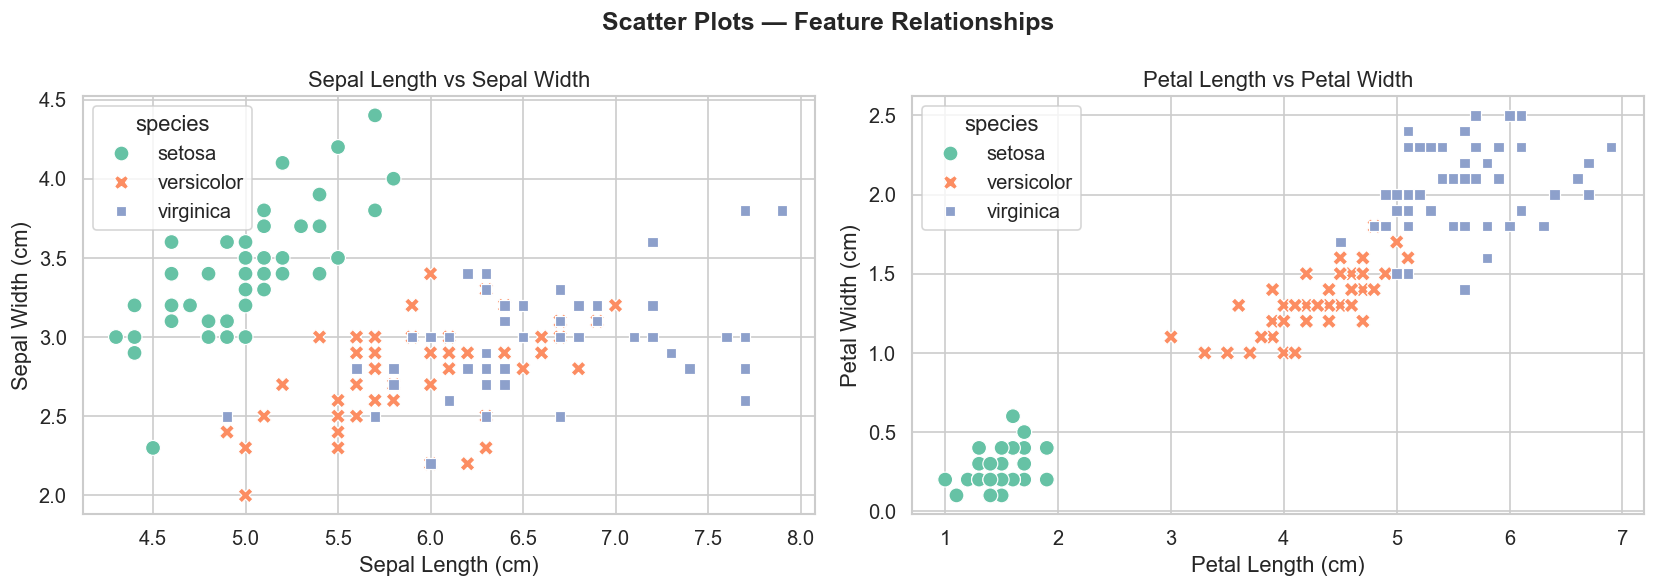

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Scatter Plots — Feature Relationships", fontsize=15, fontweight="bold")

sns.scatterplot(
    data=df, x="sepal_length", y="sepal_width",
    hue="species", style="species", s=80, ax=axes[0]
)
axes[0].set_title("Sepal Length vs Sepal Width")
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")

sns.scatterplot(
    data=df, x="petal_length", y="petal_width",
    hue="species", style="species", s=80, ax=axes[1]
)
axes[1].set_title("Petal Length vs Petal Width")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")

plt.tight_layout()
plt.savefig("scatter_plots.png", bbox_inches="tight")
plt.show()

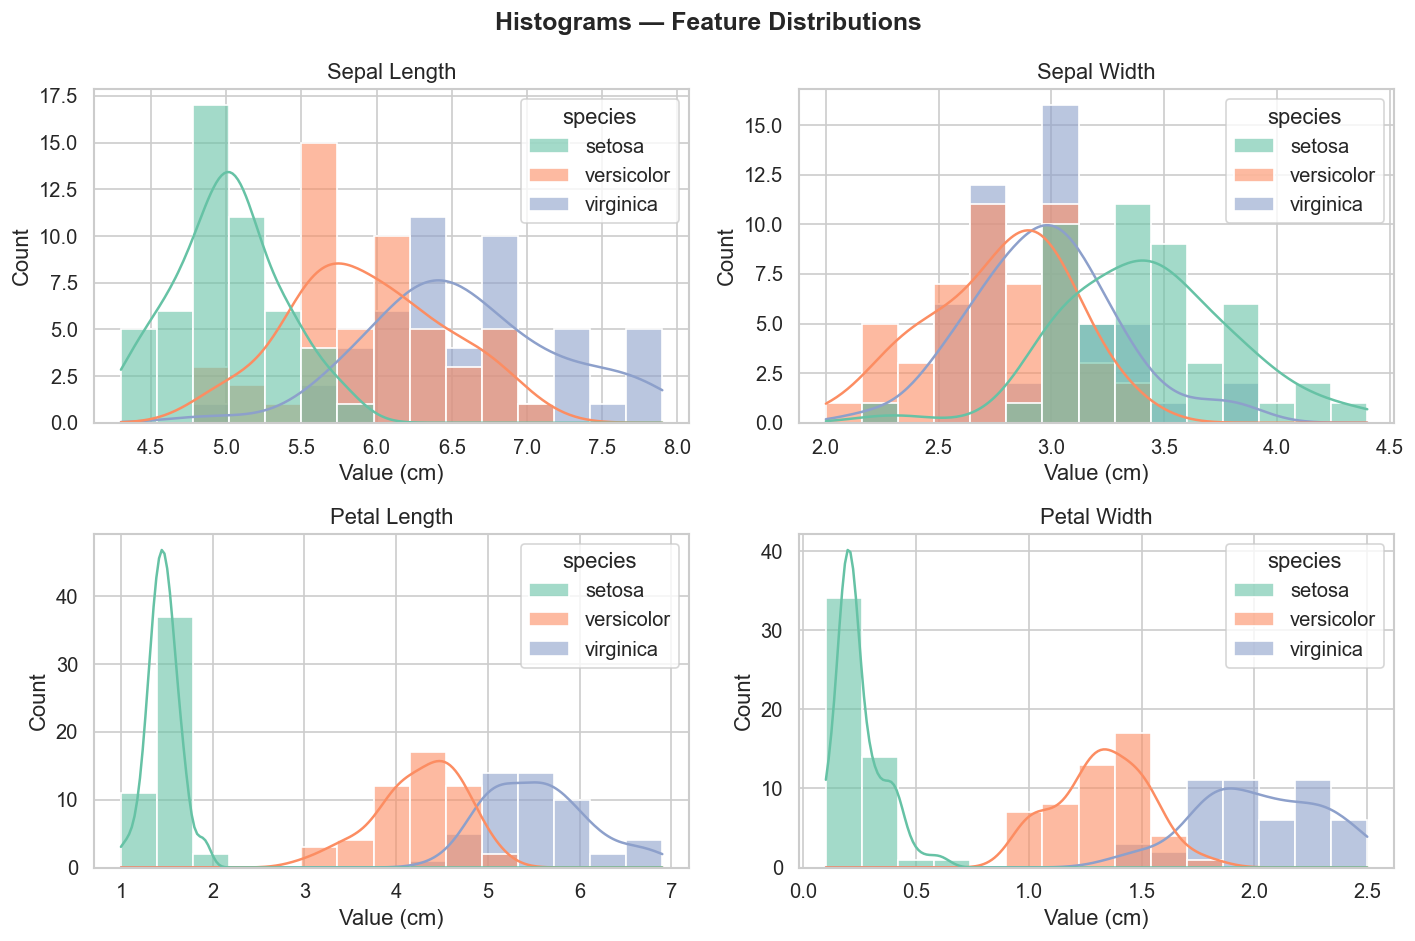

In [8]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Histograms — Feature Distributions", fontsize=15, fontweight="bold")
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(
        data=df, x=feature, hue="species",
        kde=True, bins=15, alpha=0.6, ax=ax
    )
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Value (cm)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("histograms.png", bbox_inches="tight")
plt.show()

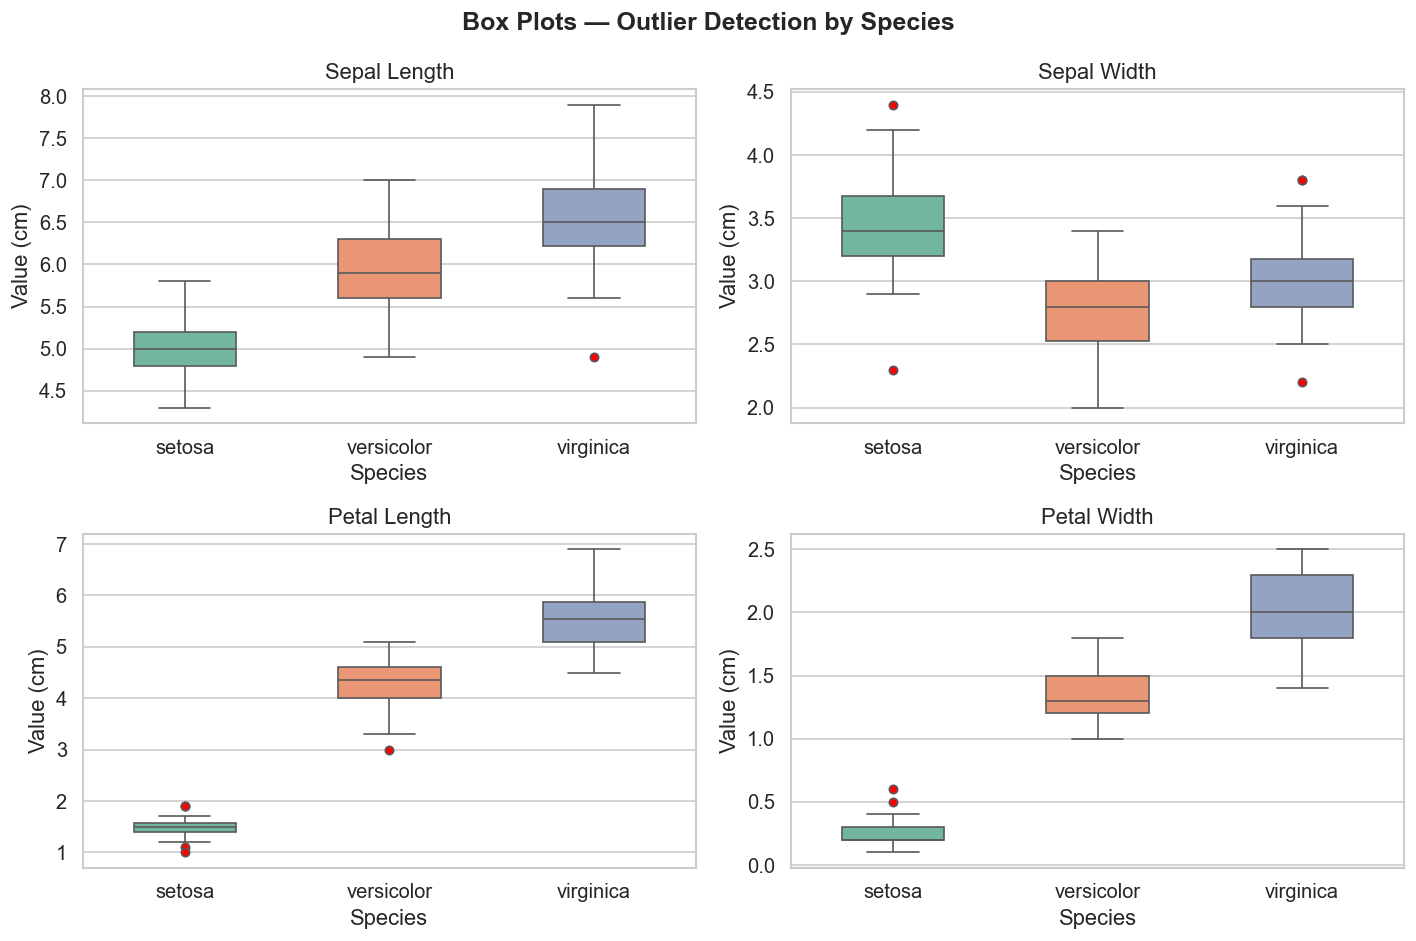

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Box Plots — Outlier Detection by Species", fontsize=15, fontweight="bold")
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.boxplot(
        data=df, x="species", y=feature,
        hue="species", legend=False,
        palette="Set2", width=0.5,
        flierprops={"marker": "o", "markerfacecolor": "red",
                    "markersize": 5, "linestyle": "none"},
        ax=ax
    )
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Species")
    ax.set_ylabel("Value (cm)")

plt.tight_layout()
plt.savefig("boxplots.png", bbox_inches="tight")
plt.show()

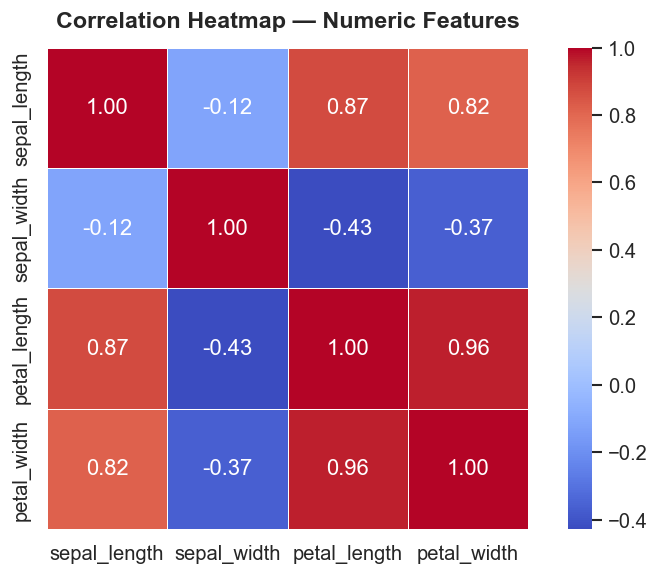

In [10]:
corr = df.drop(columns="species").corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="coolwarm", linewidths=0.5,
    square=True, ax=ax
)
ax.set_title("Correlation Heatmap — Numeric Features",
             fontsize=14, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("heatmap.png", bbox_inches="tight")
plt.show()